# ANÁLISIS EXPLORATORIO DE LOS DATOS DE UNA CAMPAÑA COMERCIAL DE BANCA PORTUGUESA

Objetivo del análisis: El objetivo de este notebook es consolidar, limpiar y analizar la información disponible sobre clientes y campaña comercial.

Dentro del trabajo de análisis realizado, se incluyen los siguientes bloques:  

1.- Importación y consolidación de las distintas fuentes de datos.  
2.- Transformación y limpieza de los datos.  
3.- Análisis descriptivo de los datos.  
4.- Visualización de los datos (librería Matplotlib).  

## 1.- Importación y consolidación de las distintas fuentes de datos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

### 1.1.- Carga de las fuentes de datos
Se importan los datos facilitados para la realización del análisis:
- bank-additional.csv: que contiene la información relativa a la campaña realizada por el banco
- customer-details2012.csv, customer-details2013.csv, customer-details2014.csv: ficheros generados a partir del Excel de datos de cliente facilitado

In [2]:
bank_add = pd.read_csv('bank-additional.csv', index_col = 0)

cust_det2012 = pd.read_csv('customer-details2012.csv', sep = ';', index_col = 0)
cust_det2013 = pd.read_csv('customer-details2013.csv', sep = ';', index_col = 0)
cust_det2014 = pd.read_csv('customer-details2014.csv', sep = ';', index_col = 0)

bank_add.head()

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


### 1.2.- Consolidación de datos y comprobación de duplicados.
- En primer lugar los tres DataFrames anuales de clientes se consolidan verticalmente en un único DataFrame mediante `pd.concat()`.
- Antes de combinar la información de clientes con los datos de la campaña, se comprueba que los campos utilizados como clave (`ID` e `id_`) no contienen valores duplicados.
- Finalmente, se homogeneiza el nombre de la clave y se realiza un `merge` de tipo left para conservar todos los clientes disponibles en la base consolidada.

In [3]:
cust_det_TOTAL = pd.concat([cust_det2012, cust_det2013, cust_det2014], axis = 0,join = 'inner')
cust_det_TOTAL.head()

,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,161770,1,0,2012-04-04 00:00:00,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,85477,1,1,2012-12-30 00:00:00,7,e9d37224-cb6f-4942-98d7-46672963d097
2,147233,1,1,2012-02-02 00:00:00,5,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,121393,1,2,2012-12-21 00:00:00,29,9991fafb-4447-451a-8be2-b0df6098d13e
4,63164,1,2,2012-06-20 00:00:00,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [4]:
registros_Id_cliente = cust_det_TOTAL.groupby('ID').size()
registros_Id_campaign = bank_add.groupby('id_').size()

if (registros_Id_cliente > 1).any() or (registros_Id_campaign > 1).any():
    print('Duplicado')
else:
    print('Sin duplicados')

Sin duplicados


In [5]:
bank_add = bank_add.rename(columns={'id_': 'ID'})
Tabla_trabajo = cust_det_TOTAL.merge(bank_add, how = 'left', on = 'ID', indicator  = True)
Tabla_trabajo = Tabla_trabajo.set_index('ID')
Tabla_trabajo.rename(columns={'_merge':'origen'}, inplace = True)

Tabla_trabajo.head()

,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,origen
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,
089b39d8-e4d0-461b-87d4-814d71e0e079,161770,1,0,2012-04-04 00:00:00,29,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261.0,1.0,999.0,0.0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,both
e9d37224-cb6f-4942-98d7-46672963d097,85477,1,1,2012-12-30 00:00:00,7,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149.0,1.0,999.0,0.0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,both
3f9f49b5-e410-4948-bf6e-f9244f04918b,147233,1,1,2012-02-02 00:00:00,5,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226.0,1.0,999.0,0.0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,both
9991fafb-4447-451a-8be2-b0df6098d13e,121393,1,2,2012-12-21 00:00:00,29,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151.0,1.0,999.0,0.0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,both
eca60b76-70b6-4077-80ba-bc52e8ebb0eb,63164,1,2,2012-06-20 00:00:00,20,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307.0,1.0,999.0,0.0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,both


## 2.- Transformación y limpieza de los datos.  

Se revisa la estructura del dataFrame consolidado (Tabla_trabajo) y se aplican las transformaciones necesarias para garantizar que las variables tengan un formato adecuado.

### 2.1.- Comprobaciones iniciales del DataFrame consolidado (Tabla_trabajo):
- Dimensiones del conjunto de datos.
- Comprobación de la no duplicidad del índice que identifica a cada cliente.
- Comprobación del número total de clientes que tienen registro en la campaña realizada.
- Resumen con el tipo inicial de cada variable.  

Resultado comprobaciones básicas: dataframe consolidado 'Tabla_trabajo' tiene 43.170 filas y 28 columnas (variables). Además, se confirma que el identificador de usuario es único. Tras la consolidación de los datos, hay 170 clientes de la BBDD de clientes que no tienen registro de haber sido consultados en la campaña.

In [6]:
Tabla_trabajo.shape

(43170, 28)

In [7]:
Tabla_trabajo.index.is_unique

True

In [8]:
Tabla_trabajo['origen'].value_counts()

origen
both          43000
left_only       170
right_only        0
Name: count, dtype: int64

### 2.2.- Revisión y transformación de los datos  

El objetivo de esta revisión es identificar qué variables no tienen un tipo correcto según el dato que contienen para poder realizar su transformación. También se realizarán transformaciones (como desglose de fechas)
que facilitarán el posterior análisis de la información.

In [9]:
Tabla_trabajo.dtypes

Income                  int64
Kidhome                 int64
Teenhome                int64
Dt_Customer               str
NumWebVisitsMonth       int64
age                   float64
job                       str
marital                   str
education                 str
default               float64
housing               float64
loan                  float64
contact                   str
duration              float64
campaign              float64
pdays                 float64
previous              float64
poutcome                  str
emp.var.rate          float64
cons.price.idx            str
cons.conf.idx             str
euribor3m                 str
nr.employed               str
y                         str
date                      str
latitude              float64
longitude             float64
origen               category
dtype: object

#### 2.2.1.- Conversión de variables numéricas almacenadas como texto.  

Algunas variables numéricas se encuentran inicialmente almacenadas como texto debido al uso de la coma como separador decimal.  
Se define una función auxiliar que sustituye la coma por un punto y convierte posteriormente el valor a `float`, manteniendo como nulos aquellos registros que no contienen información.

In [10]:
def convierte_coma(valor: str | float | None) -> float:
    """Sustituye caracter coma por punto para convertir un valor decimal con coma a tipo float manteniendo los valores nulos."""
    if pd.isna(valor):
        return np.nan
    valor = valor.replace(',', '.')
    return float(valor)

In [11]:
Tabla_trabajo['cons.price.idx'] = Tabla_trabajo['cons.price.idx'].apply(convierte_coma)
Tabla_trabajo['cons.conf.idx'] = Tabla_trabajo['cons.conf.idx'].apply(convierte_coma)
Tabla_trabajo['euribor3m'] = Tabla_trabajo['euribor3m'].apply(convierte_coma)
Tabla_trabajo['nr.employed'] = Tabla_trabajo['nr.employed'].apply(convierte_coma)

#### 2.2.2.- Conversión de variables de fecha.  

Las variables 'Dt_Customer' y 'date' tienen información correspondiente a variables de fecha pero inicialmente están almacenadas como texto. Aquí se realizan dos tipos de conversiones:
- 'Dt_Customer' presenta un formato reconocible directamente por Pandas a través de la función pd.to_datetime().
- La variable 'date' contiene el nombre del mes en formato escrito, por lo que requiere una transformación previa antes de convertirla a formato fecha. Aquí se utilizan
tres pasos para la transformación:
    - Se separan el año, mes y día a través de un .split() utilizando "-" como separador. Los valores numéricos se intentan convertir a número, si no, se deja NaN.
    - A través de un diccionario mes (alfabético-numérico) y la función .map(), se convierte la columna 'month' en valor numérico. Se consolida la nueva columna 'date'
    con formato datetime (año, mes, día) definiendo los valores no válidos como NaT.
    - Finalmente, una vez se tienen los campos que no se pueden tratar como numérica en NaN en las columnas year, month y day, se convierten a valores enteros
    para evitar visualizaciones con decimales de estos campos.

Según se dispone de la información, se incluyen columnas año-mes (Dt_Customer) o año-mes-día (date) para facilitar agrupaciones y filtrados en análisis posteriores.

In [12]:
Tabla_trabajo['Dt_Customer'] = pd.to_datetime(Tabla_trabajo['Dt_Customer'], errors = 'coerce')
Tabla_trabajo['year_customer'] = Tabla_trabajo['Dt_Customer'].dt.year.astype('Int64')
Tabla_trabajo['month_customer'] = Tabla_trabajo['Dt_Customer'].dt.month.astype('Int64')

In [13]:
Tabla_trabajo[['day', 'month', 'year']] = Tabla_trabajo['date'].str.split('-', expand = True)
Tabla_trabajo['day'] = pd.to_numeric(Tabla_trabajo['day'], errors = 'coerce').astype('float64')
Tabla_trabajo['year'] = pd.to_numeric(Tabla_trabajo['year'], errors = 'coerce').astype('float64')
Tabla_trabajo = Tabla_trabajo.drop(columns = 'date')

meses_text_num = {'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6, 'julio': 7, 'agosto': 8, 'septiembre': 9,
'octubre': 10, 'noviembre': 11, 'diciembre': 12}
Tabla_trabajo['month'] = Tabla_trabajo['month'].map(meses_text_num).astype('float64')
Tabla_trabajo['date'] = pd.to_datetime({'year': Tabla_trabajo['year'], 'month': Tabla_trabajo['month'], 'day': Tabla_trabajo['day']}, errors='coerce')

Tabla_trabajo['year'] = Tabla_trabajo['year'].astype('Int64')
Tabla_trabajo['month'] = Tabla_trabajo['month'].astype('Int64')
Tabla_trabajo['day'] = Tabla_trabajo['day'].astype('Int64')

#### 2.2.3.- Tratamiento de la variable `pdays`

Se revisa la distribución de valores de `pdays` mediante un contador de repetición de cada valor, observándose una presencia muy elevada del valor 999. Este valor no 
se considera representativo y, debido a su alta repetición (41412 registros) se opta por convertir a NA de cara a evitar que distorsione cualquier medida estadística.
Al ser una variable entera, se convierten todos los registros de la variable a integer.

In [14]:
Tabla_trabajo['pdays'].value_counts()
Tabla_trabajo['pdays'] = Tabla_trabajo['pdays'].replace(999, pd.NA).astype('Int64')

#### 2.2.4.- Conversión de la variable de éxito de la campaña `y`
La variable `y` indica el resultado de la campaña y se encuentra inicialmente almacenada como texto, con los valores `yes` y `no`. Para facilitar posteriores cálculos y agrupaciones, se transforma a tipo booleano.

In [15]:
def y_a_booleano(numero: str | None) -> bool | None:
    """Convierte los valores 'yes' y 'no' a booleanos, manteniendo como nulos el resto de valores."""
    if numero == 'yes':
        return True
    elif numero == 'no':
        return False
    else:
        return None

Tabla_trabajo['y'] = Tabla_trabajo['y'].apply(y_a_booleano).astype('boolean')

#### 2.2.5.- Conversión de variables binarias a booleanas
Se convierte a tipo boolean las variables que tienen valores con 0 y 1: 'default', 'housing', 'loan' a booleanas.

In [16]:
columnas_booleanas = ['default', 'housing', 'loan']
for i in columnas_booleanas:
    Tabla_trabajo[i] = Tabla_trabajo[i].astype('boolean')

### 2.3.- Resumen final de las variables del dataset

Una vez realizadas las transformaciones y conversiones necesarias, se construye un DataFrame resumen para comprobar la estructura final del conjunto de datos.

Para ello se recorren todas las columnas de `Tabla_trabajo` y, en función de su tipo de dato, se calculan distintas métricas:

- Para todas las variables se obtiene el tipo de dato, el número total de registros y el número de registros no nulos.
- Para las variables booleanas se muestran los valores posibles del total que son verdaderos o falsos.
- Para las variables numéricas se calculan el valor mínimo, máximo y la media.
- Para las variables de fecha se muestran la fecha mínima y máxima.
- Para el resto de variables, string, se obtiene una lista con los valores únicos que contienen.

El resultado se almacena en `resumen_dataset`, utilizando como índice el nombre de cada variable del dataset original.

In [17]:
lista_dataset = []

for columna in Tabla_trabajo.columns:
    tipo_dato = Tabla_trabajo[columna].dtype
    
    if pd.api.types.is_bool_dtype(Tabla_trabajo[columna]) == True:
        lista_dataset.append({
            'Columna dataset': columna,
            'Tipo variable': tipo_dato,
            'Nºregistros': Tabla_trabajo[columna].size,
            'Registros no nulos': Tabla_trabajo[columna].count(),
            'Mínimo': None,
            'Máximo': None,
            'Media': None,
            'Valores posibles': Tabla_trabajo[columna].dropna().unique().tolist()
        })
    
    elif pd.api.types.is_numeric_dtype(Tabla_trabajo[columna]) == True:
        lista_dataset.append({
            'Columna dataset': columna,
            'Tipo variable': tipo_dato,
            'Nºregistros': Tabla_trabajo[columna].size,
            'Registros no nulos': Tabla_trabajo[columna].count(),
            'Mínimo': round(Tabla_trabajo[columna].min(), 4),
            'Máximo': round(Tabla_trabajo[columna].max(), 4),
            'Media': round(Tabla_trabajo[columna].mean(), 4),
            'Valores posibles': None
        })
    
    elif pd.api.types.is_datetime64_any_dtype(Tabla_trabajo[columna]) == True:
        lista_dataset.append({
            'Columna dataset': columna,
            'Tipo variable': tipo_dato,
            'Nºregistros': Tabla_trabajo[columna].size,
            'Registros no nulos': Tabla_trabajo[columna].count(),
            'Mínimo': Tabla_trabajo[columna].min(),
            'Máximo': Tabla_trabajo[columna].max(),
            'Media': None,
            'Valores posibles': None
        })
    
    else:
        lista_dataset.append({
            'Columna dataset': columna,
            'Tipo variable': tipo_dato,
            'Nºregistros': Tabla_trabajo[columna].size,
            'Registros no nulos': Tabla_trabajo[columna].count(),
            'Mínimo': None,
            'Máximo': None,
            'Media': None,
            'Valores posibles': Tabla_trabajo[columna].dropna().unique().tolist()
        })

resumen_dataset = pd.DataFrame(lista_dataset)
resumen_dataset = resumen_dataset.set_index('Columna dataset')
resumen_dataset

,Tipo variable,Nºregistros,Registros no nulos,Mínimo,Máximo,Media,Valores posibles
Columna dataset,,,,,,,
Income,int64,43170,43170,5841,180802,93227.3896,None
Kidhome,int64,43170,43170,0,2,1.0047,None
Teenhome,int64,43170,43170,0,2,0.9986,None
Dt_Customer,datetime64[us],43170,43170,2012-01-01 00:00:00,2014-12-31 00:00:00,NaN,None
NumWebVisitsMonth,int64,43170,43170,1,32,16.5913,None
age,float64,43170,37880,17.0,98.0,39.9771,None
job,str,43170,42655,None,None,NaN,"[housemaid, services, admin., blue-collar, technician, retired, management, unemployed, self-employed, entrepreneur, student]"
marital,str,43170,42915,None,None,NaN,"[MARRIED, SINGLE, DIVORCED]"
education,str,43170,41193,None,None,NaN,"[basic.4y, high.school, basic.6y, basic.9y, professional.course, university.degree, illiterate]"


## 3.- Análisis descriptivo de los datos.

Una vez consolidado y transformado el dataset, se realiza un análisis descriptivo con el objetivo de conocer las principales características de las variables y analizar su relación con el resultado de la campaña comercial.

El análisis se estructura en tres partes:
- Análisis estadístico de las variables numéricas.
- Análisis de la distribución de las variables no numéricas.
- Análisis de la relación entre distintas características del cliente y el resultado de la campaña `y`.

### 3.1.- Análisis descriptivo de las variables numéricas

Se utiliza `describe()` para obtener los principales estadísticos descriptivos de las variables numéricas del dataset:

- `count`: total de registros no nulos
- `mean`: media
- `std`: desviación estándar
- `min`: mínimo
- `25%`: primer cuartil
- `50%`: mediana
- `75%`: tercer cuartil
- `max`: máximo

Los resultados se redondean a dos decimales y se transponen para facilitar su lectura, mostrando cada variable en una fila.

In [18]:
Tabla_trabajo.describe(include = ['Int64', 'Float64']).round(2).T

,count,mean,std,min,25%,50%,75%,max
Income,43170.0,93227.39,50498.18,5841.0,49608.0,93009.5,136740.5,180802.0
Kidhome,43170.0,1.0,0.82,0.0,0.0,1.0,2.0,2.0
Teenhome,43170.0,1.0,0.82,0.0,0.0,1.0,2.0,2.0
NumWebVisitsMonth,43170.0,16.59,9.24,1.0,9.0,17.0,25.0,32.0
age,37880.0,39.98,10.44,17.0,32.0,38.0,47.0,98.0
duration,43000.0,257.74,258.67,0.0,102.0,179.0,319.0,4918.0
campaign,43000.0,2.57,2.77,1.0,1.0,2.0,3.0,56.0
pdays,1588.0,6.07,3.86,0.0,3.0,6.0,7.0,27.0
previous,43000.0,0.17,0.5,0.0,0.0,0.0,0.0,7.0
emp.var.rate,43000.0,0.08,1.57,-3.4,-1.8,1.1,1.4,1.4


### 3.2. Análisis descriptivo de las variables no numéricas

A continuación se revisan las variables categóricas y booleanas del dataset y se analiza la distribución de sus valores.
Para cada una de estas variables, se crea un Dataframe con el total de registros que tiene cada valor y su peso porcentual sobre el total de registros de la variable.

In [19]:
resumen_dataset.loc[resumen_dataset['Tipo variable'].astype('str').isin(['str','boolean'])]

,Tipo variable,Nºregistros,Registros no nulos,Mínimo,Máximo,Media,Valores posibles
Columna dataset,,,,,,,
job,str,43170,42655,None,None,NaN,"[housemaid, services, admin., blue-collar, technician, retired, management, unemployed, self-employed, entrepreneur, student]"
marital,str,43170,42915,None,None,NaN,"[MARRIED, SINGLE, DIVORCED]"
education,str,43170,41193,None,None,NaN,"[basic.4y, high.school, basic.6y, basic.9y, professional.course, university.degree, illiterate]"
default,boolean,43170,34019,None,None,NaN,"[False, True]"
housing,boolean,43170,41974,None,None,NaN,"[False, True]"
loan,boolean,43170,41974,None,None,NaN,"[False, True]"
contact,str,43170,43000,None,None,NaN,"[telephone, cellular]"
poutcome,str,43170,43000,None,None,NaN,"[NONEXISTENT, FAILURE, SUCCESS]"
y,boolean,43170,43000,None,None,NaN,"[False, True]"


#### 3.2.1.- DataFrame resumen columna 'job'.

In [20]:
conteo_job = Tabla_trabajo['job'].value_counts(dropna=False)
resumen_job = pd.DataFrame({'Nºregistros': conteo_job, '%total': (conteo_job / conteo_job.sum() * 100).round(2)})
resumen_job

,Nºregistros,%total
job,,
admin.,10873,25.19
blue-collar,9654,22.36
technician,7026,16.28
services,4162,9.64
management,3050,7.07
retired,1790,4.15
entrepreneur,1522,3.53
self-employed,1489,3.45
housemaid,1123,2.60


#### 3.2.2.- DataFrame resumen columna 'marital'.

In [21]:
conteo_marital = Tabla_trabajo['marital'].value_counts(dropna=False)
resumen_marital = pd.DataFrame({'Nºregistros': conteo_marital, '%total': (conteo_marital / conteo_marital.sum() * 100).round(2)})
resumen_marital

,Nºregistros,%total
marital,,
MARRIED,25999,60.22
SINGLE,12105,28.04
DIVORCED,4811,11.14
NaN,255,0.59


#### 3.2.3.- DataFrame resumen columna 'education'.

In [22]:
conteo_education = Tabla_trabajo['education'].value_counts(dropna=False)
resumen_education = pd.DataFrame({'Nºregistros': conteo_education, '%total': (conteo_education / conteo_education.sum() * 100).round(2)})
resumen_education

,Nºregistros,%total
education,,
university.degree,12722,29.47
high.school,9925,22.99
basic.9y,6309,14.61
professional.course,5477,12.69
basic.4y,4356,10.09
basic.6y,2386,5.53
NaN,1977,4.58
illiterate,18,0.04


#### 3.2.4.- DataFrame resumen columna 'contact'.

In [23]:
conteo_contact = Tabla_trabajo['contact'].value_counts(dropna=False)
resumen_contact = pd.DataFrame({'Nºregistros': conteo_contact, '%total': (conteo_contact / conteo_contact.sum() * 100).round(2)})
resumen_contact

,Nºregistros,%total
contact,,
cellular,27396,63.46
telephone,15604,36.15
NaN,170,0.39


#### 3.2.5.- DataFrame resumen columna 'poutcome'.

In [24]:
conteo_poutcome = Tabla_trabajo['poutcome'].value_counts(dropna=False)
resumen_poutcome = pd.DataFrame({'Nºregistros': conteo_poutcome, '%total': (conteo_poutcome / conteo_poutcome.sum() * 100).round(2)})
resumen_poutcome

,Nºregistros,%total
poutcome,,
NONEXISTENT,37103,85.95
FAILURE,4461,10.33
SUCCESS,1436,3.33
NaN,170,0.39


### 3.3.- Tasa de éxito de la campaña
- Resumen global de la variable 'y'.
- Tasa de éxito de la campaña sin tener en cuenta los valores nulos: 'tasa_exito'.

In [25]:
conteo_y = Tabla_trabajo['y'].value_counts(dropna=False)
resumen_y = pd.DataFrame({'Nºregistros': conteo_y, '%total': (conteo_y / conteo_y.sum() * 100).round(2)})
resumen_y

,Nºregistros,%total
y,,
False,38156,88.39
True,4844,11.22
<NA>,170,0.39


In [26]:
tasa_exito = round(Tabla_trabajo['y'].mean() * 100, 2)
tasa_exito

np.float64(11.27)

### 3.4.- Evolución de la campaña y contexto económico
De cara a valorar el posible impacto de factores macroeconómicos facilitados en el set de datos, se realiza un análisis para comprobar, en función del año de realización
de la acción comercial, los siguientes valores:
- Número de clientes incluidos en la acción comercial.
- Valores medidos de: tasa de empleo, IPC, confianza del consumidor y euribor.
- Total de clientes con éxito en la campaña y porcentaje correspondiente sobre el total.

Como conclusión, no se observa una relación clara entre ninguna de las variables analizadas y la tasa de éxito.

In [27]:
clientes_eur_exito = Tabla_trabajo.dropna(subset=['year', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'y']).copy()
tasa_exito1 = clientes_eur_exito.groupby('year').agg(Clientes=('euribor3m', 'count'),Tasa_empleo=('emp.var.rate', 'mean'), IPC=('cons.price.idx', 'mean'),
Confianza_consumidor=('cons.conf.idx', 'mean'), Euribor_medio=('euribor3m', 'mean'), Exito=('y','sum'),).round(3)
tasa_exito1['Porc_exito'] = round((tasa_exito1['Exito']/tasa_exito1['Clientes'])*100,2)
tasa_exito1

,Clientes,Tasa_empleo,IPC,Confianza_consumidor,Euribor_medio,Exito,Porc_exito
year,,,,,,,
2015,6607,0.087,93.569,-40.485,3.630,734,11.11
2016,6627,0.087,93.581,-40.448,3.626,788,11.89
2017,6749,0.055,93.575,-40.577,3.584,750,11.11
2018,6641,0.086,93.580,-40.512,3.618,766,11.53
2019,6569,0.095,93.584,-40.547,3.635,742,11.3


### 3.5. Creación de variables auxiliares para el análisis

Para facilitar el análisis posterior se generan nuevas variables a partir de la información ya disponible en el dataset.

Se crean cuatro variables auxiliares:

- `CustMonth_tenure`: antigüedad del cliente, expresada en meses, en el momento en que se realizó la acción comercial.
- `CustMonth_category`: agrupación de la antigüedad del cliente en cuatro intervalos.
- `age_category`: agrupación de la edad del cliente en cuatro grandes categorías.
- `Call_time(min)`: duración de la llamada expresada en minutos, a partir de la variable original `duration`, almacenada en segundos.

In [28]:
Tabla_trabajo['CustMonth_tenure'] = ((Tabla_trabajo['date'].dt.year - Tabla_trabajo['Dt_Customer'].dt.year)*12 + (Tabla_trabajo['date'].dt.month
                                    - Tabla_trabajo['Dt_Customer'].dt.month))

In [29]:
def categorizar_antiguedad(meses: int | float | None) -> str:
    """Agrupa la antigüedad del cliente en cuatro intervalos."""
    if pd.isna(meses):
        return 'Sin dato'
    elif meses < 12:
        return '1. Menos de 1 año'
    elif meses < 36:
        return '2. Entre 1 y 3 años'
    elif meses <= 60:
        return '3. Entre 3 y 5 años'
    else:
        return '4. Más de 5 años'
    
Tabla_trabajo['CustMonth_category'] = Tabla_trabajo['CustMonth_tenure'].apply(categorizar_antiguedad)

In [30]:
def categorizar_edad (numero: int | float | None) -> str:
    """Agrupa la edad de los clientes en cuatro grandes intervalos."""
    if pd.isna(numero):
        return 'Sin dato'
    elif 17 <= numero <= 28:
        return '1. Joven adulto'
    elif 29 <= numero <= 39:
        return '2. Adulto joven'
    elif 40 <= numero <= 50:
        return '3. Mediana edad'
    elif 51 <= numero <= 98:
        return '4. Adultos mayores'
    else:
        return 'Dato fuera de rango definido'

Tabla_trabajo['age_category'] = Tabla_trabajo['age'].apply(categorizar_edad)

In [31]:
Tabla_trabajo['Call_time(min)'] = Tabla_trabajo['duration']/60

### 3.6.- Perfil del cliente y relación con el éxito de la campaña

#### 3.6.1.- Nivel medio de ingresos por edad y profesión

In [32]:
Tabla_trabajo[Tabla_trabajo['age_category'] != 'Sin dato'].pivot_table(values = 'Income', index = 'age_category', columns = 'job', aggfunc = 'mean').round(0).astype('Int64')

job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed
age_category,,,,,,,,,,,
1. Joven adulto,91912,93110,83669,72691,84755,101835,97343,91691,96430,97426,95996
2. Adulto joven,93262,92745,95609,97628,92629,106126,95199,92956,86890,92081,94357
3. Mediana edad,94449,94042,95709,101641,94299,87425,90890,92232,87926,95262,95927
4. Adultos mayores,94421,89860,89999,96688,94055,93309,96197,92065,<NA>,93029,89337


#### 3.6.2.- Porcentaje de éxito en función de la antigüedad de los clientes

In [33]:
antig_exito = Tabla_trabajo.dropna(subset=['CustMonth_category', 'y']).copy()
antig_exito = antig_exito.groupby('CustMonth_category').agg(Exito= ('y', 'sum',), Total= ('y', 'count',))
antig_exito['Porc_Exito'] = round((antig_exito['Exito']/antig_exito['Total'])*100,2)
antig_exito

,Exito,Total,Porc_Exito
CustMonth_category,,,
1. Menos de 1 año,264,1286,20.53
2. Entre 1 y 3 años,1590,10140,15.68
3. Entre 3 y 5 años,1981,17605,11.25
4. Más de 5 años,976,13721,7.11
Sin dato,33,248,13.31


#### 3.6.3.- Porcentaje de éxito en función de la edad de los clientes

In [34]:
edad_exito = Tabla_trabajo.dropna(subset=['age_category', 'y']).copy()
edad_exito = edad_exito.groupby('age_category').agg(Exito= ('y', 'sum',), Total= ('y', 'count',))
edad_exito['Porc_Exito'] = round((edad_exito['Exito']/edad_exito['Total'])*100,2)
edad_exito

,Exito,Total,Porc_Exito
age_category,,,
1. Joven adulto,684,3916,17.47
2. Adulto joven,1745,16959,10.29
3. Mediana edad,847,10445,8.11
4. Adultos mayores,990,6560,15.09
Sin dato,578,5120,11.29


#### 3.6.4.- Porcentaje de éxito con respecto al resultado de la campaña anterior

In [35]:
old_exito = Tabla_trabajo.dropna(subset=['poutcome', 'y']).copy()
old_exito = old_exito.groupby('poutcome').agg(Exito= ('y', 'sum',), Total= ('y', 'count',))
old_exito['Porc_Exito'] = round((old_exito['Exito']/old_exito['Total'])*100,2)
old_exito

,Exito,Total,Porc_Exito
poutcome,,,
FAILURE,635,4461,14.23
NONEXISTENT,3271,37103,8.82
SUCCESS,938,1436,65.32


#### 3.6.5.- Porcentaje de éxito con respecto a la profesión de los clientes

In [36]:
job_exito = Tabla_trabajo.dropna(subset=['job', 'y']).copy()
job_exito = job_exito.groupby('job').agg(Exito= ('y', 'sum',), Total= ('y', 'count',))
job_exito['Porc_Exito'] = round((job_exito['Exito']/job_exito['Total'])*100,2)
job_exito

,Exito,Total,Porc_Exito
job,,,
admin.,1415,10873,13.01
blue-collar,665,9654,6.89
entrepreneur,126,1522,8.28
housemaid,111,1123,9.88
management,342,3050,11.21
retired,451,1790,25.2
self-employed,161,1489,10.81
services,336,4162,8.07
student,283,903,31.34


#### 3.6.6.- Porcentaje de éxito con respecto al estado civil de los clientes

In [37]:
state_exito = Tabla_trabajo.dropna(subset=['marital', 'y']).copy()
state_exito = state_exito.groupby('marital').agg(Exito= ('y', 'sum',), Total= ('y', 'count',))
state_exito['Porc_Exito'] = round((state_exito['Exito']/state_exito['Total'])*100,2)
state_exito

,Exito,Total,Porc_Exito
marital,,,
DIVORCED,490,4811,10.18
MARRIED,2655,25999,10.21
SINGLE,1686,12105,13.93


#### 3.6.7.- Porcentaje de éxito con respecto al nivel educativo de los clientes

In [38]:
educ_exito = Tabla_trabajo.dropna(subset=['education', 'y']).copy()
educ_exito = educ_exito.groupby('education').agg(Exito= ('y', 'sum',), Total= ('y', 'count',))
educ_exito['Porc_Exito'] = round((educ_exito['Exito']/educ_exito['Total'])*100,2)
educ_exito

,Exito,Total,Porc_Exito
education,,,
basic.4y,448,4356,10.28
basic.6y,194,2386,8.13
basic.9y,493,6309,7.81
high.school,1076,9925,10.84
illiterate,4,18,22.22
professional.course,620,5477,11.32
university.degree,1748,12722,13.74


#### 3.6.8.- Porcentaje de éxito con respecto al tipo de contacto realizado

In [39]:
tipcontact_exito = Tabla_trabajo.dropna(subset=['contact', 'y']).copy()
tipcontact_exito = tipcontact_exito.groupby('contact').agg(Exito= ('y', 'sum',), Total= ('y', 'count',))
tipcontact_exito['Porc_Exito'] = round((tipcontact_exito['Exito']/tipcontact_exito['Total'])*100,2)
tipcontact_exito

,Exito,Total,Porc_Exito
contact,,,
cellular,4039,27396,14.74
telephone,805,15604,5.16


#### 3.6.9.- Porcentaje de éxito con respecto al número de contactos realizados

In [40]:
contact_exito = Tabla_trabajo.dropna(subset=['campaign', 'y']).copy()
contact_exito = contact_exito.groupby('campaign').agg(Exito= ('y', 'sum',), Total= ('y', 'count',))
contact_exito['Porc_Exito'] = round((contact_exito['Exito']/contact_exito['Total'])*100,2)
contact_exito

,Exito,Total,Porc_Exito
campaign,,,
1.0,2396,18404,13.02
2.0,1268,11048,11.48
3.0,604,5584,10.82
4.0,258,2777,9.29
5.0,123,1658,7.42
6.0,79,1025,7.71
7.0,40,658,6.08
8.0,20,418,4.78
9.0,16,289,5.54


#### 3.6.10.- Análisis de la duración de llamada por año y mes, en función de si la campaña tiene o no éxito

In [41]:
Tabla_trabajo[Tabla_trabajo['Call_time(min)'] > 0].pivot_table(values = 'Call_time(min)', index = ['year', 'month'], columns = 'y',
                                                               aggfunc = ['count', 'mean', 'median']).round(2)

count        mean        median      
y          False True  False  True   False True 
year month                                      
2015 1       625    81  3.47   9.70   2.60  6.73
     2       632    77  3.58   9.24   2.73  7.67
     3       687    78  3.63   7.53   2.67  6.01
     4       655    64  3.67   9.25   2.68  8.49
     5       631    84  3.80   9.48   2.82  7.28
     6       632    68  3.65   9.94   2.68  8.91
     7       644    69  3.72  10.39   2.80  7.12
     8       588    86  3.73   9.54   2.88  7.39
     9       630    83  3.55   8.96   2.71  6.73
     10      623    88  3.72   9.69   2.92  8.23
     11      623    78  3.76   8.74   2.82  7.61
     12      643    73  3.51   7.91   2.67  6.43
2016 1       615    96  3.78   8.25   2.67  6.19
     2       628    72  3.73   9.49   2.88  7.37
     3       651    75  3.73   9.88   2.67  6.92
     4       616    80  3.81   9.04   2.65  7.70
     5       622    70  3.66   9.28   2.70  7.26
     6       638    96  3.95   8.59   2.72  7.02
     7       615    84  3.71  10.13   2.80  8.62
     8       627    79  3.70   8.30   2.75  7.55
     9       646    81  3.61   9.87   2.81  7.23
     10      630   105  3.64  10.24   2.62  8.83
     11      630    74  3.95   8.80   2.83  6.49
     12      617    85  3.59   9.08   2.67  7.77
2017 1       633    83  3.68   9.39   2.70  7.15
     2       633    79  3.65  10.99   2.77  9.13
     3       625    76  3.84   9.99   2.75  7.86
     4       618    83  4.15   9.25   3.07  8.05
     5       649    67  3.57   9.28   2.75  8.23
     6       606    80  3.85   9.03   2.75  6.70
     7       622    67  3.63   8.05   2.77  6.18
     8       666    77  3.73   9.57   2.66  7.47
     9       672    63  3.77   8.50   2.78  7.08
     10      648    94  3.55   9.19   2.78  7.47
     11      625    89  3.72   9.56   2.73  8.40
     12      626    81  3.54   8.42   2.59  6.87
2018 1       617    60  3.51   9.58   2.58  8.42
     2       634    80  3.44   9.18   2.62  7.10
     3       596    79  3.97   8.58   2.88  7.18
     4       688    94  3.70   8.34   2.75  7.14
     5       644    79  3.61   9.32   2.67  7.95
     6       629    96  3.50   9.34   2.65  8.68
     7       630    99  3.77   8.64   2.68  7.12
     8       610    82  3.44   8.85   2.56  6.74
     9       620    65  3.56  10.41   2.60  8.62
     10      625    76  3.76   8.73   2.80  7.53
     11      670    89  3.56   9.00   2.68  7.42
     12      606    80  3.56   8.14   2.56  7.87
2019 1       619    88  3.74   9.86   2.65  8.28
     2       651    90  3.67   9.80   2.57  7.60
     3       644    77  3.71   9.83   2.76  8.33
     4       604    80  3.75   9.19   2.85  6.95
     5       624    77  3.40   9.89   2.58  8.95
     6       632    61  3.70   9.49   2.85  6.93
     7       672    91  3.75   9.29   2.75  8.18
     8       630    80  3.48   9.90   2.57  8.06
     9       635    74  3.68   9.43   2.90  7.83
     10      627    82  3.70   7.92   2.70  5.87
     11      641    84  3.53   9.36   2.67  8.38
     12      618    83  3.63   8.28   2.72  6.13

#### 3.6.11.- Euribor medio por año y mes en función de si la campaña tiene o no éxito

In [42]:
Tabla_trabajo[Tabla_trabajo['euribor3m'] > 0].pivot_table(values = 'euribor3m', index = ['year', 'month'], columns = 'y', aggfunc = 'mean').round(2)

y           False  True 
year month              
2015 1       3.79   2.25
     2       4.02   2.20
     3       3.71   1.74
     4       3.88   1.87
     5       3.74   2.47
     6       3.81   2.77
     7       3.76   2.12
     8       3.71   2.24
     9       3.97   1.61
     10      3.78   2.09
     11      3.88   1.96
     12      3.78   1.70
2016 1       3.77   1.76
     2       3.75   1.83
     3       3.87   1.70
     4       3.87   2.35
     5       3.82   2.13
     6       3.74   2.19
     7       3.72   2.27
     8       3.96   1.93
     9       3.80   2.20
     10      3.90   2.13
     11      3.80   2.46
     12      3.96   2.35
2017 1       3.79   1.93
     2       3.68   1.97
     3       3.72   1.98
     4       3.73   2.01
     5       3.68   2.16
     6       3.74   1.92
     7       3.75   2.00
     8       3.83   2.11
     9       3.87   1.96
     10      3.84   2.01
     11      3.87   1.87
     12      3.82   2.19
2018 1       3.91   2.27
     2       3.91   2.18
     3       3.74   2.36
     4       3.75   2.06
     5       3.81   2.18
     6       3.85   1.95
     7       3.83   1.99
     8       3.73   2.14
     9       3.62   2.27
     10      3.82   2.32
     11      3.88   2.03
     12      3.84   2.32
2019 1       3.88   2.39
     2       3.83   2.25
     3       3.73   2.05
     4       3.65   2.13
     5       3.81   2.13
     6       3.90   2.49
     7       3.85   2.47
     8       3.86   2.44
     9       3.87   2.17
     10      3.78   1.80
     11      3.88   2.24
     12      3.77   1.76

#### 3.6.12.- Nivel de confianza del consumidor por año y mes en función de si la campaña tiene o no éxito

In [43]:
Tabla_trabajo[Tabla_trabajo['cons.conf.idx'] < 0].pivot_table(values = 'cons.conf.idx', index = ['year', 'month'], columns = 'y', aggfunc = 'mean').round(2)

y           False  True 
year month              
2015 1     -40.56 -39.67
     2     -40.55 -39.43
     3     -41.10 -39.36
     4     -40.27 -38.95
     5     -40.76 -40.20
     6     -40.48 -39.21
     7     -40.58 -38.98
     8     -40.43 -39.97
     9     -40.11 -39.58
     10    -40.94 -39.32
     11    -40.53 -38.88
     12    -40.80 -39.48
2016 1     -40.60 -39.40
     2     -40.50 -38.65
     3     -40.63 -40.20
     4     -40.54 -39.13
     5     -40.97 -40.69
     6     -40.71 -39.76
     7     -40.64 -39.97
     8     -40.83 -40.30
     9     -40.44 -38.86
     10    -40.59 -39.82
     11    -40.53 -38.90
     12    -40.33 -39.20
2017 1     -40.41 -39.35
     2     -40.82 -41.27
     3     -40.80 -39.62
     4     -40.67 -40.59
     5     -40.56 -41.20
     6     -40.78 -38.75
     7     -40.70 -39.41
     8     -40.36 -40.25
     9     -40.58 -40.19
     10    -40.95 -39.71
     11    -40.74 -39.84
     12    -40.25 -39.35
2018 1     -40.35 -40.91
     2     -40.65 -39.63
     3     -40.67 -39.23
     4     -40.56 -39.96
     5     -40.51 -40.12
     6     -40.46 -40.46
     7     -40.67 -39.87
     8     -40.84 -39.93
     9     -40.53 -41.41
     10    -40.72 -40.15
     11    -40.46 -39.07
     12    -40.38 -39.87
2019 1     -40.87 -40.43
     2     -40.63 -40.27
     3     -40.58 -39.78
     4     -40.79 -39.00
     5     -40.63 -39.41
     6     -40.49 -39.88
     7     -40.66 -40.63
     8     -40.42 -40.20
     9     -40.36 -38.97
     10    -40.83 -40.05
     11    -40.57 -39.35
     12    -40.58 -40.03

### 3.7.- Exportación de los datos
Se cierra el bloque exportando el conjunto de datos transformado a un fichero CSV.

In [44]:
Tabla_trabajo.to_csv('Tabla_trabajo.csv', index = True, sep = ';', encoding = 'utf-8-sig')

## 4.- Visualización de los datos (librería Matplotlib).

### 4.1.- Gráfico 1: barras verticales
Se construye un gráfico de barras que muestra el porcentaje de éxito de la campaña en función de la antigüedad de los clientes a partir del subset de datos generado en el punto 3.6.2. Los pasos seguidos son los siguientes:
- Definición del lienzo del gráfico.
- Definición de los ejes X e Y del gráfico.
- Parametrización del gráfico.
- Visualización final.

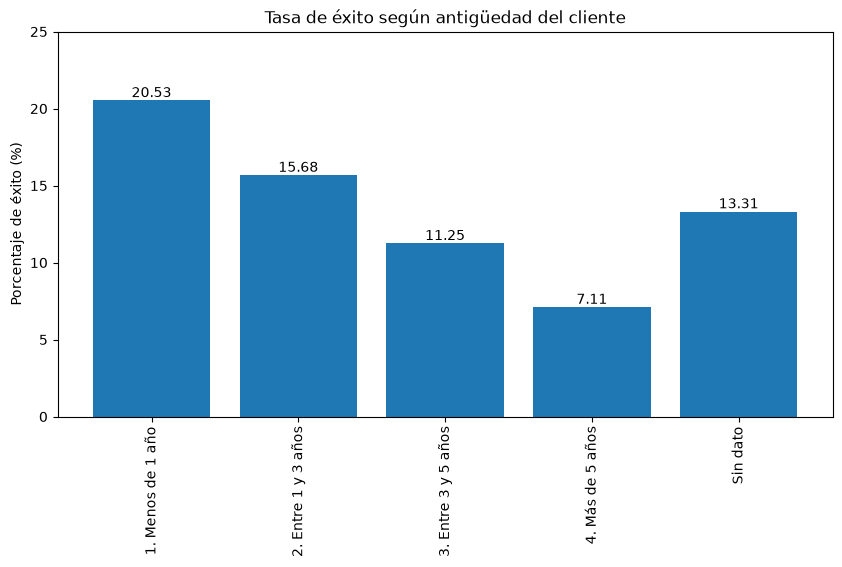

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))
 
barras_ver = ax.bar(antig_exito.index, antig_exito['Porc_Exito'])

ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('Porcentaje de éxito (%)')
ax.set_title('Tasa de éxito según antigüedad del cliente')
ax.bar_label(barras_ver)
ax.set_ylim(0, 25)

plt.show()

### 4.2.- Gráfico 2: barras horizontales
Porcentaje de éxito por tipo de trabajo (subset generado en el punto 3.6.5). Los pasos seguidos para la construcción del gráfico son los siguientes:
- Ordenación de los valores de manera ascendente para tener una visualización de los mayores porcentajes en la parte superior.
- Definición de los ejes X e Y del gráfico.
- Parametrización del gráfico.
- Visualización final.

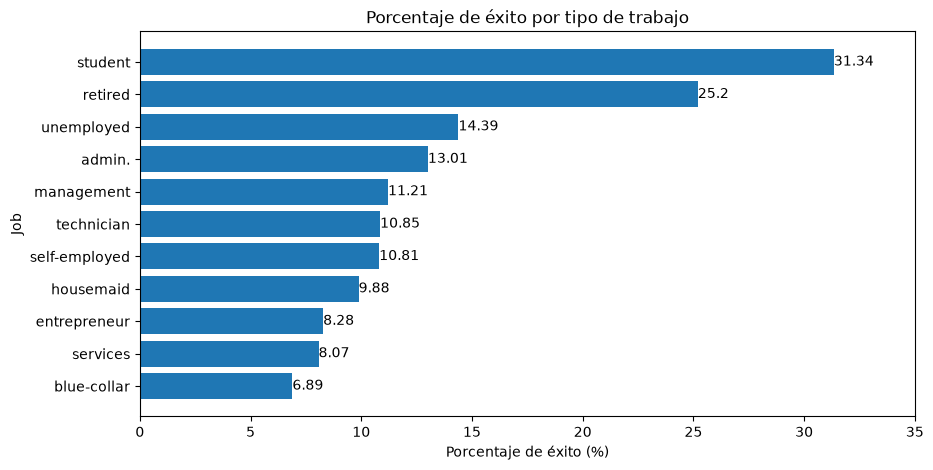

In [46]:
job_exito_desc = job_exito.sort_values(by='Porc_Exito', ascending = True)
fig, ax = plt.subplots(figsize=(10, 5))

barras_hor = ax.barh(job_exito_desc.index, job_exito_desc['Porc_Exito'])

ax.set_ylabel('Job')
ax.set_xlabel('Porcentaje de éxito (%)')
ax.set_title('Porcentaje de éxito por tipo de trabajo')
ax.bar_label(barras_hor)
ax.set_xlim(0, 35)

plt.show()

### 4.3.- Gráfico 3: gráfico de líneas
El subset de datos utilizado es el generado en el punto 3.6.9. Se incluyen únicamente los niveles de número de contactos que cuentan con más de 100 registros, evitando interpretar porcentajes calculados sobre grupos muy pequeños. Los pasos seguidos para la construcción del gráfico son los siguientes:
- Eliminación de registros con menos de 100 datos (se considera muestra no representativa).
- Se pone el valor correspondiente en cada uno de los puntos del gráfico indicando su posición relativa con respecto al mismo.
- Etiquetas de ejes y título del gráfico.
- Visualización final.

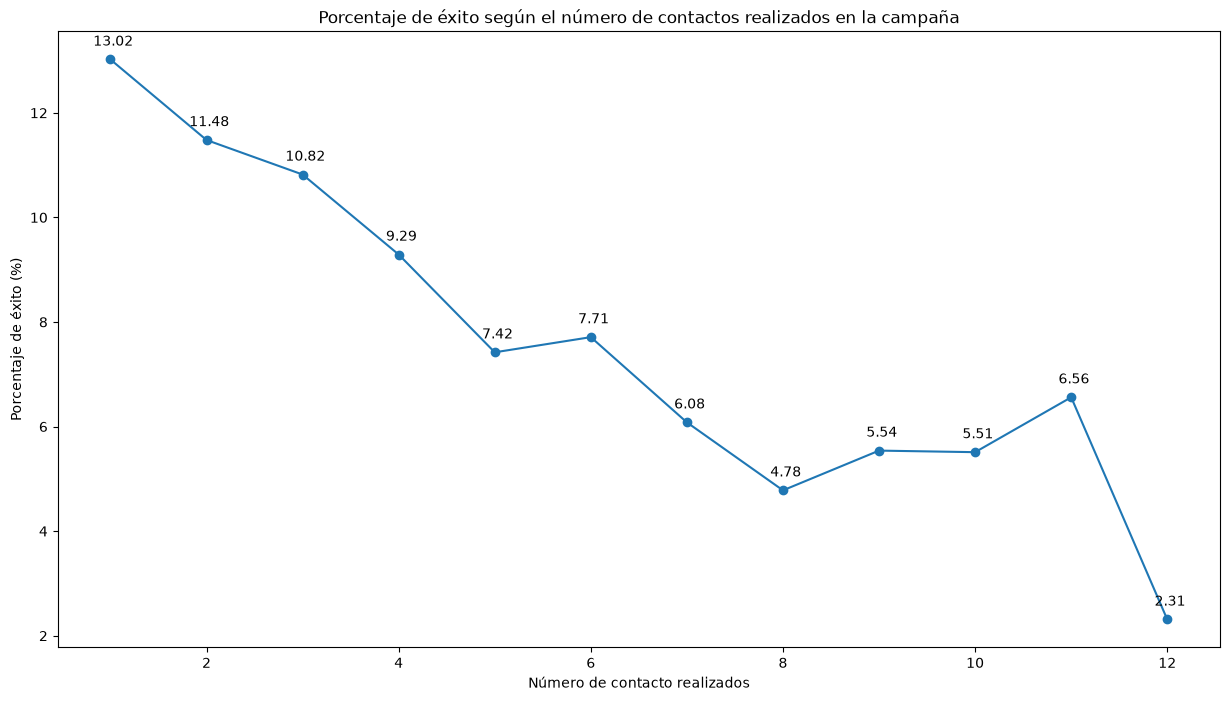

In [47]:
contact_exito_100 = contact_exito[contact_exito['Total']>100]
fig, ax = plt.subplots(figsize=(15, 8))
ax.plot(contact_exito_100.index, contact_exito_100['Porc_Exito'], marker='o')

for x, y in zip(contact_exito_100.index, contact_exito_100['Porc_Exito']):
    ax.annotate(y, (x, y),
                xytext=(2, 10),
                textcoords='offset points',
                ha='center')

ax.set_ylabel('Porcentaje de éxito (%)')
ax.set_xlabel('Número de contacto realizados')
ax.set_title('Porcentaje de éxito según el número de contactos realizados en la campaña')

plt.show()

### 4.4.- Gráfico 4: gráfico combinado de barras y líneas
A partir del subset de datos del punto 3.6.9, se genera un gráfico que indica, en barras, el número total de clientes que han sido contactados de 1 a n veces, mientras que en la línea se indica el porcentaje de éxito que ha tenido la campaña según el número de contactos realizados. Los pasos realizados para la construcción del gráfico son:
- Definición del lienzo del gráfico.
- Parametrización del gráfico (parte barras).
- Parametrización del gráfico (parte líneas).
- Visualización final.

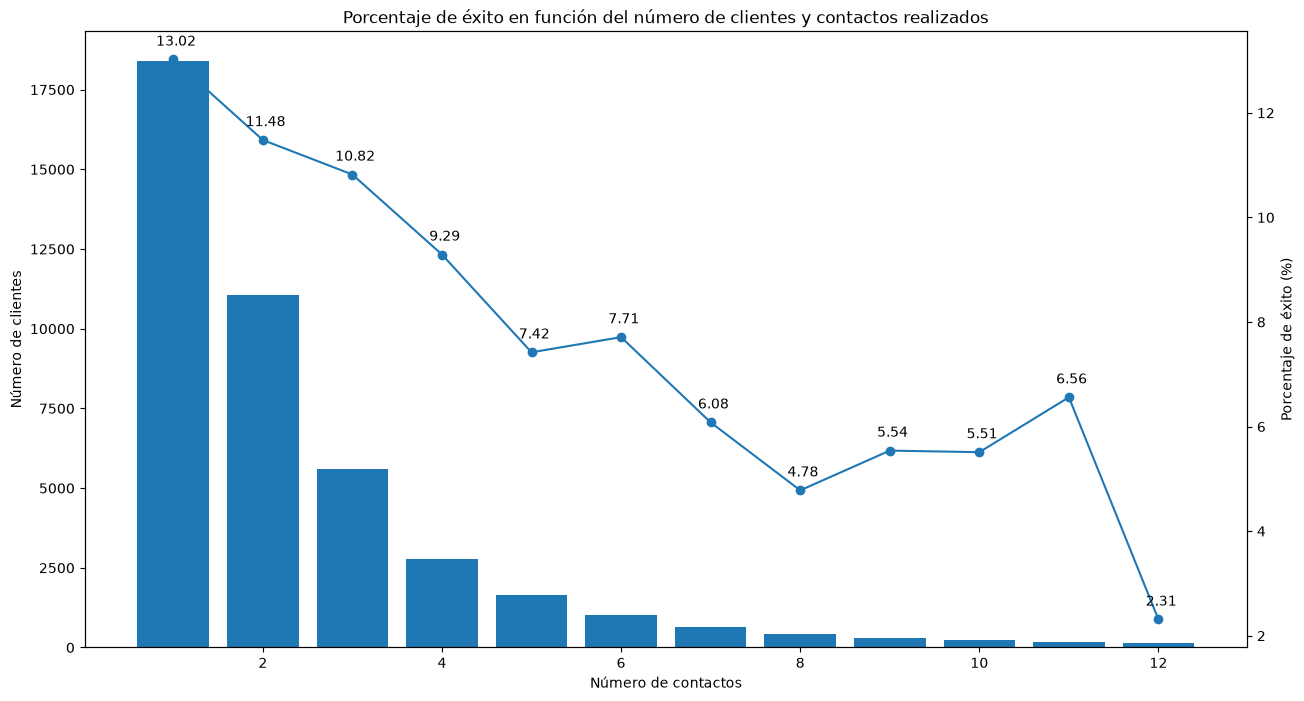

In [48]:
fig, ax1 = plt.subplots(figsize=(15, 8))

barras_ver = ax1.bar(contact_exito_100.index, contact_exito_100['Total'])
ax1.set_xlabel('Número de contactos')
ax1.set_ylabel('Número de clientes')
ax1.set_title('Porcentaje de éxito en función del número de clientes y contactos realizados')

ax2 = ax1.twinx()
ax2.plot(contact_exito_100.index, contact_exito_100['Porc_Exito'], marker='o')
ax2.set_ylabel('Porcentaje de éxito (%)')
for x, y in zip(contact_exito_100.index, contact_exito_100['Porc_Exito']):
    ax2.annotate(y, (x, y), xytext=(2, 10), textcoords='offset points', ha='center')

plt.show()

### 4.5.- Gráfico 5: histograma
A partir del DataFrame 'Tabla_trabajo' se representa la distribución de la edad de los clientes mediante un histograma dividido en 10 intervalos (bins). Los pasos que se siguen para la construcción del gráfico son:
- Definición del lienzo del gráfico.
- Definición del gráfico tipo histograma:
    - Registros del campo edad eliminando todos aquellos que no tienen dato.
    - Valor de agrupación utilizado.
    - Anchura de las columnas.
    - Color del borde de las columnas.
- Parametrización del gráfico.
- Visualización final.

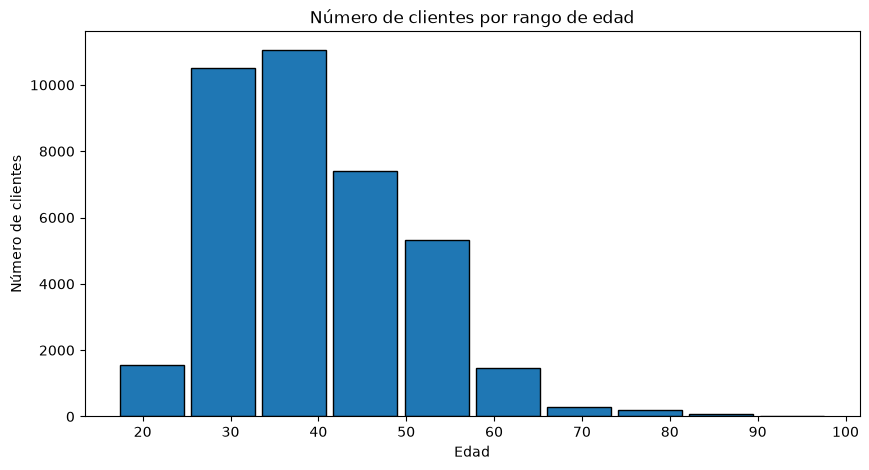

In [49]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    Tabla_trabajo['age'].dropna(),
    bins=10,
    rwidth=0.9,
    edgecolor='black'
)

ax.set_xlabel('Edad')
ax.set_ylabel('Número de clientes')
ax.set_title('Número de clientes por rango de edad')

plt.show()

### 4.6.- Gráfico 6: diagrama de cajas (boxplot)
En este gráfico se ha utilizado el DataFrame 'Tabla_trabajo', el gráfico compara la distribución de la duración de las llamadas según el resultado de la campaña. El diagrama de cajas permite visualizar la mediana, los cuartiles, la dispersión y los posibles valores atípicos de ambos grupos. Los pasos seguidos para la construcción del gráfico son:
- En el primer bloque se filtran los datos no nulos que por un lado han tenido éxito en la campaña y por otro lado los que no lo han tenido.
- Definición del lienzo del gráfico.
- Parametrización del gráfico.
- Visualización final.

In [50]:
duracion_si_exito = Tabla_trabajo.loc[Tabla_trabajo['y'] == True, 'Call_time(min)'].dropna()
duracion_no_exito = Tabla_trabajo.loc[Tabla_trabajo['y'] == False,'Call_time(min)'].dropna()

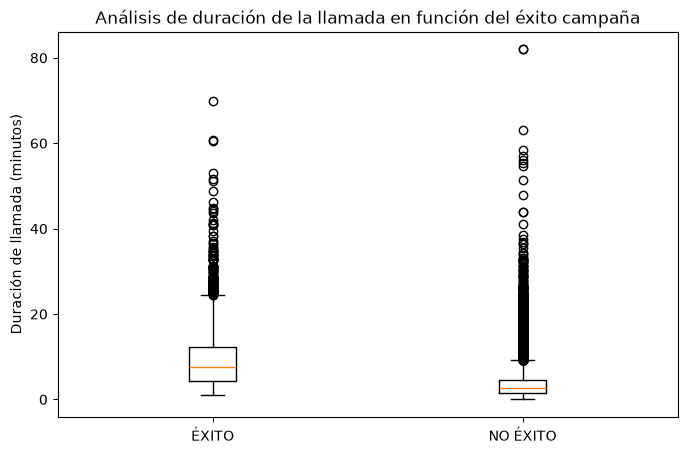

In [51]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot([duracion_si_exito, duracion_no_exito], tick_labels=['ÉXITO','NO ÉXITO'])
ax.set_ylabel('Duración de llamada (minutos)')
ax.set_title('Análisis de duración de la llamada en función del éxito campaña')

plt.show()